In [2]:
#############################################################################################################
# Program Name         : Base Price Optimization
# Client               : Case Study
# Project              : Base Price Optimization
# Location             : 
# Description          : This program defines:
#                          - product importance to busines x Elasticity, simulating a balance matrix
#                          - metrics for price optimization
#                          - Price Optimization Model
#                          - Scenario Forecasting
# Produced by          : Felipe de Souza Santos
# Modified by          : 
# Date                 : 29 Jun 2026
#############################################################################################################

#### Libraries that will be used in this code

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize
from sympy import Symbol
from scipy import stats

#### Importing the Excel with raw data

In [4]:
# Loading each sheet from the shared Case Study Data

all_sheets = pd.read_excel('Case_Study_Data.xlsx', sheet_name=None)

for sheet_name, df in all_sheets.items():
    globals()[f"df_{sheet_name}"] = df
    print("%s loaded" %(sheet_name))
    #print("")
    #print(globals()[f"df_{sheet_name}"].head(2))

Product_Retailer_Data loaded
Price_Groups loaded
Slope_Groups loaded
Business_Constraints loaded


#### Treating the data

In [5]:
print("Product_Retailer_Data")
print("File size: %s" %(df_Product_Retailer_Data['PRODUCT_ID'].count()))
df_Product_Retailer_Data = df_Product_Retailer_Data.drop_duplicates(subset=['PRODUCT_ID', 'RETAILER'])
print("File size deduped: %s" %(df_Product_Retailer_Data['PRODUCT_ID'].count()))
print("")

print("Slope_Groups")
print("File size: %s" %(df_Slope_Groups['PRODUCT_ID'].count()))
df_Slope_Groups = df_Slope_Groups.drop_duplicates(subset=['PRODUCT_ID'])
print("File size deduped: %s" %(df_Slope_Groups['PRODUCT_ID'].count()))

Product_Retailer_Data
File size: 600
File size deduped: 600

Slope_Groups
File size: 100
File size deduped: 100


#### Determining Product Importance

In [6]:
"""Importance is built per category, otherwise you will compare slow selling categories with high selling. 
In the end, only hig selling would get the price investment"""

# Importance = Units (importance to Retailer) + Margin1 (Importance to Manufact) + Margin2 (Importance to Retailer)

#Simplifying the Data Set name

df_temp = df_Product_Retailer_Data.copy()

In [7]:
#### Refining the Slope Idea as a df
df_temp = pd.merge(df_temp,df_Slope_Groups[['PRODUCT_ID', 'IS_ANCHOR','ANCHOR_PRODUCT_ID',
                                           'MIN_MAP_PER_UNIT_RATIO', 'MAX_MAP_PER_UNIT_RATIO']], 
                   on = 'PRODUCT_ID', how = 'left')

df_temp2 = df_temp[['PRODUCT_ID', 'RETAILER', 'L52W_MAP']]
df_temp2.rename(columns={'L52W_MAP': 'AnchorPromoPrice'}, inplace=True)
df_temp = pd.merge(df_temp,df_temp2, on = ['PRODUCT_ID', 'RETAILER'], how = 'left')
df_temp.head()

,PRODUCT_ID,CATEGORY,BRAND,PRODUCT_DESCRIPTION,FORM,SIZE_VALUE,UOM,PRICE_GROUP,SLOPE_GROUP,RETAILER,...,L52W_BASE_PRICE,L52W_LIST_PRICE,L52W_MAP,COGS,OWN_PRICE_ELASTICITY,IS_ANCHOR,ANCHOR_PRODUCT_ID,MIN_MAP_PER_UNIT_RATIO,MAX_MAP_PER_UNIT_RATIO,AnchorPromoPrice
0,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Walmart Corp-RMA,...,4.44,3.10,3.95,1.69,-0.57,YES,A001,0.97,1.03,3.95
1,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Target Corp-RMA,...,4.71,3.11,4.23,1.11,-0.52,YES,A001,0.97,1.03,4.23
2,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Kroger Corp-RMA,...,4.71,2.90,3.96,1.15,-0.52,YES,A001,0.97,1.03,3.96
3,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Albertsons Corp-RMA,...,5.20,3.27,4.48,1.64,-0.47,YES,A001,0.97,1.03,4.48
4,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,CVS Corp-RMA,...,5.24,3.51,4.53,1.60,-0.45,YES,A001,0.97,1.03,4.53


In [8]:
df_temp['Units'] = df_temp['L52W_VOLUME']
df_temp['Margin_Manufact'] = (df_temp['L52W_LIST_PRICE']/df_temp['COGS'])-1
df_temp['Margin_Retailer'] = (df_temp['L52W_BASE_PRICE']/df_temp['L52W_LIST_PRICE'])-1
df_temp = df_temp.fillna(0)
### Normalize Variables

cols_to_normalize = ['Units', 'Margin_Retailer', 'Margin_Manufact']

df_temp[cols_to_normalize] = df_temp[cols_to_normalize].apply(lambda x: (x - x.min()) / (x.max() - x.min()))


def Product_Score(Units, Margin_Retailer, Margin_Manufact):
    if Units > 0.5 and Margin_Retailer > 0.5 and Margin_Manufact > 0.5: #High Unit Sales, High Margin both
        Score = 3
    elif Units > 0.5 and Margin_Retailer < 0.5 and Margin_Manufact < 0.5: #High Unit Sales, Low Margin for Both
        Score = 2
    elif Units > 0.5 and Margin_Retailer > 0.5 and Margin_Manufact < 0.5: #High Unit Sales, High margin Retail
        Score = 2.5   
    elif Units > 0.5 and Margin_Retailer < 0.5 and Margin_Manufact > 0.5: #High Unit Sales, High margin Manufct
        Score = 2.75  
    elif Units < 0.5 and Margin_Retailer > 0.5 and Margin_Manufact > 0.5: #Low Unit Sales, High margin Both
        Score = 2
    elif Units < 0.5 and Margin_Retailer > 0.5 and Margin_Manufact > 0.5: #Low Unit Sales, Low margin Both
        Score = 0.5
    elif Units < 0.5 and Margin_Retailer < 0.5 and Margin_Manufact > 0.5: #Low Unit Sales, Low margin Ret
        Score = 1.5      
    elif Units < 0.5 and Margin_Retailer < 0.5 and Margin_Manufact > 0.5: #Low Unit Sales, Low margin Manu
        Score = 1       
    else:
        Score = 1      
    return Score

df_temp['Product_Imp_Score'] = \
df_temp[['Units', 'Margin_Retailer', 'Margin_Manufact']]\
                                        .apply(lambda x: Product_Score(*x), axis=1)

df_temp['Product_Imp_Score2'] = df_temp['Units']+df_temp['Margin_Manufact']+df_temp['Margin_Retailer']

In [9]:
df_temp.query("CATEGORY == 'ANALGESICS'").sort_values(by='Product_Imp_Score', ascending=False).head(5)

,PRODUCT_ID,CATEGORY,BRAND,PRODUCT_DESCRIPTION,FORM,SIZE_VALUE,UOM,PRICE_GROUP,SLOPE_GROUP,RETAILER,...,IS_ANCHOR,ANCHOR_PRODUCT_ID,MIN_MAP_PER_UNIT_RATIO,MAX_MAP_PER_UNIT_RATIO,AnchorPromoPrice,Units,Margin_Manufact,Margin_Retailer,Product_Imp_Score,Product_Imp_Score2
240,A049,ANALGESICS,EXCEDRIN,EXCEDRIN CAPLET 24 CT,CAPLET,24,CT,EXCEDRIN_24CT,EXCEDRIN_CAPLET_SLOPE,Walmart Corp-RMA,...,YES,A049,0.97,1.03,4.01,0.625396,0.854762,0.612577,3.0,2.092735
80,A017,ANALGESICS,ADVIL,ADVIL PM CAPLET 40 CT,PM CAPLET,40,CT,ADVIL_40CT,ADVIL_PM CAPLET_SLOPE,Walmart Corp-RMA,...,YES,A017,0.97,1.03,6.29,0.548216,0.763696,0.567026,3.0,1.878939
20,A005,ANALGESICS,ADVIL,ADVIL TABLET 24 CT,TABLET,24,CT,ADVIL_24CT,ADVIL_TABLET_SLOPE,Walmart Corp-RMA,...,YES,A005,0.97,1.03,4.25,0.702576,0.127290,0.725824,2.5,1.555689
60,A013,ANALGESICS,ADVIL,ADVIL GELCAP 40 CT,GELCAP,40,CT,ADVIL_40CT,ADVIL_GELCAP_SLOPE,Walmart Corp-RMA,...,YES,A013,0.97,1.03,7.83,0.643536,0.038544,0.528229,2.5,1.210309
280,A057,ANALGESICS,EXCEDRIN,EXCEDRIN TENSION HEADACHE 24 CT,TENSION HEADACHE,24,CT,EXCEDRIN_24CT,EXCEDRIN_TENSION HEADACHE_SLOPE,Walmart Corp-RMA,...,YES,A057,0.97,1.03,4.22,0.635150,0.397464,0.851806,2.5,1.884419


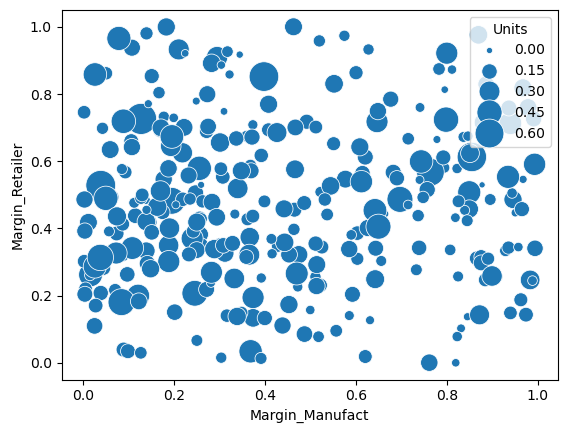

In [10]:
### Print Example of CATEGORY = 'ANALGESICS'
sns.scatterplot(data=df_temp.query("CATEGORY == 'ANALGESICS'"), x='Margin_Manufact', y='Margin_Retailer', size='Units', sizes=(20, 500))
plt.show()

### Determining best Pricing Strategy (balance matrix) given the elasticity + product Importance

In [11]:
#Elasticity Cut-Off per Category

Elasticity_Cutoff = df_temp['OWN_PRICE_ELASTICITY'].quantile(0.5)
Product_Imp_Score_Cutoff = 1.2
def BalanceMatrix(Importance, Elasticity):

    if Importance > Product_Imp_Score_Cutoff and Elasticity < Elasticity_Cutoff:
        PP_Reco_EN = 'High Elast + Price Investment Room'
    elif Importance > Product_Imp_Score_Cutoff and Elasticity >= Elasticity_Cutoff:
        PP_Reco_EN = 'Low Elast + Price Investment Room'
    elif Importance <= Product_Imp_Score_Cutoff and Elasticity < Elasticity_Cutoff:
        PP_Reco_EN =  'High Elast + No Price Investment Room'
    elif Importance <= Product_Imp_Score_Cutoff and Elasticity >= Elasticity_Cutoff:
        PP_Reco_EN = 'Low Elast + No Price Investment Room'
    else:
        PP_Reco_EN = 'N/A'
        
    return PP_Reco_EN

df_temp['Price_Strategy'] = df_temp[['Product_Imp_Score2','OWN_PRICE_ELASTICITY']]\
                                    .apply(lambda x: BalanceMatrix(*x), axis=1)

##### Creating the metrics that we will use as % of for the constraints

In [12]:
df_temp['ActualManufactMargin'] = (df_temp['L52W_LIST_PRICE']-df_temp['COGS'])*df_temp['L52W_VOLUME']
df_temp['ActualManufactSales'] = (df_temp['L52W_LIST_PRICE'])*df_temp['L52W_VOLUME']
df_temp['RetailSales'] = (df_temp['L52W_BASE_PRICE'])*df_temp['L52W_VOLUME']
df_temp['ActualRetailtMargin'] = (df_temp['L52W_BASE_PRICE']-df_temp['L52W_LIST_PRICE'])*df_temp['L52W_VOLUME']

### Price Optimizer

In [13]:
"""This optimization problem is a nonlinear programming (NLP) model with nonlinear objective and constraints due 
   to the logistic pricing function, elasticity-based demand, and ratio-based margin constraints. 
   If additional discrete pricing or grouping decisions are introduced, the formulation becomes 
   a mixed-integer nonlinear programming (MINLP) problem. Since all the decision variables are continuous
   (DiscountMin, DiscountMax, and INCL for each product), this problem is well suited for 
   scipy.optimize.minimize using either the trust-constr or SLSQP method."""

'This optimization problem is a nonlinear programming (NLP) model with nonlinear objective and constraints due \n   to the logistic pricing function, elasticity-based demand, and ratio-based margin constraints. \n   If additional discrete pricing or grouping decisions are introduced, the formulation becomes \n   a mixed-integer nonlinear programming (MINLP) problem. Since all the decision variables are continuous\n   (DiscountMin, DiscountMax, and INCL for each product), this problem is well suited for \n   scipy.optimize.minimize using either the trust-constr or SLSQP method.'

In [27]:
def PriceOptimizer(scenario,OptVariable,PriceVariationMin,PriceVariationMax, C1_Units_Variation, C3_Manufact_Sales_Var, \
                   C4_Manufact_Margin_Var,C5_EachRetailer_Margin_Var,C6_Each_Retailer_Toward_25,\
                   ProductImportanceInclination, MinInclination, Optmethod):

    global FinalDF
    global df
    global ModelParameters

    print("Running Scenario: %s" %(scenario))
    print("")
    InvestmentMax = (-1)*df_temp['ActualManufactMargin'].sum()*C4_Manufact_Margin_Var
    SalesVarMax = (-1)*df_temp['ActualManufactSales'].sum()*C3_Manufact_Sales_Var
    OptVariable = 'Margin'
    DiscountMin = 100+PriceVariationMin
    DiscountMax = 100+PriceVariationMax
    INCL = ProductImportanceInclination
    MinInclination  = MinInclination
    UnitsGtZero=df_temp['L52W_VOLUME'].sum()*C1_Units_Variation
    Optmethod=Optmethod #SLSQP #COBYLA #'trust-constr'
    
    WMT_Max_Investment = df_temp.query("RETAILER == 'Walmart Corp-RMA'")['ActualRetailtMargin'].sum()*C5_EachRetailer_Margin_Var
    TGT_Max_Investment = df_temp.query("RETAILER == 'Target Corp-RMA'")['ActualRetailtMargin'].sum()*C5_EachRetailer_Margin_Var
    CVS_Max_Investment = df_temp.query("RETAILER == 'CVS Corp-RMA'")['ActualRetailtMargin'].sum()*C5_EachRetailer_Margin_Var
    ALB_Max_Investment = df_temp.query("RETAILER == 'Albertsons Corp-RMA'")['ActualRetailtMargin'].sum()*C5_EachRetailer_Margin_Var
    KRG_Max_Investment = df_temp.query("RETAILER == 'Kroger Corp-RMAA'")['ActualRetailtMargin'].sum()*C5_EachRetailer_Margin_Var

    df = df_temp.copy()
    df['Prod_Imp_CutOff'] = Product_Imp_Score_Cutoff
    df['Prod_Imp_CutOff2'] = Product_Imp_Score_Cutoff
    def SCurve(Member_Imp, Member_imp_Cut, Actual_Price):
    
        S_Price_Temp = "((((({DiscountMin} - {DiscountMax}) / (1 + np.exp((" + str(float(Member_Imp - Member_imp_Cut)) \
                 + ")*{INCL}))) + {DiscountMax})*(" + str(float(Actual_Price)) + "))/100)"
    
        S_Price = (((((DiscountMin - DiscountMax) / \
                      (1 + np.exp(((Member_Imp - Member_imp_Cut)*INCL))) + DiscountMax)*((Actual_Price))))/100) 
        return pd.Series((S_Price,S_Price_Temp))
    
    
    df[['S_Price1','S_Price_Temp1']] = \
    df[['Product_Imp_Score','Prod_Imp_CutOff','L52W_LIST_PRICE']].apply(lambda x: SCurve(*x), axis=1)
    
    df[['S_Price2','S_Price_Temp2']] = \
    df[['Product_Imp_Score2','Prod_Imp_CutOff2','L52W_LIST_PRICE']].apply(lambda x: SCurve(*x), axis=1)

    df['S_Discount1'] =  df['S_Price1']/df['L52W_LIST_PRICE'] -1
    df['S_Discount2'] =  df['S_Price2']/df['L52W_LIST_PRICE'] -1
    df['S_Discount2'] = df['S_Discount2']*(-1)
    df = df.sort_values(by='Product_Imp_Score2', ascending=False)
    area = df['Units'].astype('float')
    x = df['Product_Imp_Score2'].astype('float')
    y = df['S_Discount2'].astype('float')
    Disc_max = df['S_Discount1'].max()+0.01
    Disc_min = df['S_Discount1'].min()-0.01
    
    ax = sns.scatterplot(data=df, x='Product_Imp_Score2', y='S_Discount2', size='Units', sizes=(20, 500))
    ax.invert_xaxis()
    print("Ideal S-Surve, with no constraints or optimization")
    plt.show()
    print("")
 
    def MarginBestPrice(Regular_Cost, Units_non_Promo, Regular_Price,Elasticity,retail_base_price,BP_LP_Ratio):
    
        x = Symbol("x")
        z = Symbol("z")
    
        UnitsVar = (((Units_non_Promo + (Units_non_Promo*(((x*BP_LP_Ratio)/retail_base_price) -1)*(Elasticity))) - Units_non_Promo))
        
        TotalUnits = (Units_non_Promo + \
                      Units_non_Promo*(((x*BP_LP_Ratio)/retail_base_price) -1)*(Elasticity))
        
        CostNew = ((Units_non_Promo + \
                      Units_non_Promo*((x/Regular_Price) -1)*(Elasticity))*Regular_Cost)
        
        NewSales = ((Units_non_Promo + Units_non_Promo*((x/Regular_Price) -1)*(Elasticity))*x) - \
                    (Units_non_Promo*Regular_Price)
        
        TotalMargin = ((((Units_non_Promo + \
                      Units_non_Promo*((x/Regular_Price) -1)*(Elasticity))*x) - \
                        ((Units_non_Promo + \
                      Units_non_Promo*((x/Regular_Price) -1)*(Elasticity))*Regular_Cost)) \
                       - ((Units_non_Promo*Regular_Price) - (Units_non_Promo*Regular_Cost)))
    
        retailer_margin_var = ((((Units_non_Promo + \
                      Units_non_Promo*(((x*BP_LP_Ratio)/retail_base_price) -1)*(Elasticity))*(x*BP_LP_Ratio)) - \
                        ((Units_non_Promo + \
                      Units_non_Promo*(((x*BP_LP_Ratio)/retail_base_price) -1)*(Elasticity))*Regular_Price)) \
                       - ((Units_non_Promo*retail_base_price) - (Units_non_Promo*Regular_Price)))
        
        #retailer_margin_var = ((Units_non_Promo*((x*BP_LP_Ratio) - x)) - (Units_non_Promo*(retail_base_price - Regular_Price)))
        
        retailer_margin_var_pct = ((((Units_non_Promo + \
                      Units_non_Promo*(((x*BP_LP_Ratio)/retail_base_price) -1)*(Elasticity))*(x*BP_LP_Ratio)) - \
                        ((Units_non_Promo + \
                      Units_non_Promo*(((x*BP_LP_Ratio)/retail_base_price) -1)*(Elasticity))*Regular_Price)) \
                       / ((Units_non_Promo*retail_base_price) - (Units_non_Promo*Regular_Price)))
        
        PriceBase = Regular_Price
        NewPrice = x
    
        PriceVar = (x/Regular_Price -1)
    
        return pd.Series((TotalMargin, UnitsVar, NewSales, TotalUnits,PriceBase,NewPrice,retailer_margin_var,retailer_margin_var_pct,PriceVar))

    df['BP_LP_Ratio'] = (df['L52W_BASE_PRICE']/df['L52W_LIST_PRICE'])
    df['PromoRatio'] = (df['L52W_MAP']/df['L52W_BASE_PRICE'])

    df[['FxMarginVar', 'FxUnitsVar', 'FxSales', 'FxUnits','FxBasePrice','FxNewPrice','FxRetailerMarginVar','Fxretailer_margin_var_pct','FxPriceVar']] = \
    df[['COGS', 'L52W_VOLUME', 'L52W_LIST_PRICE','OWN_PRICE_ELASTICITY','L52W_BASE_PRICE','BP_LP_Ratio']]\
    .apply(lambda x: MarginBestPrice(*x), axis=1)

    df['Sales'] = df['L52W_VOLUME']*df['L52W_BASE_PRICE']
    Totals = df['Sales'].sum()
    df["SPD_PCT"] = df['Sales']/Totals

    def Equations(S_CPI, Member_Imp, Member_imp_Cut, Competitor_Price, \
                   Regular_Price, Regular_Cost, SPD_PCT, FxMarginVar,\
                   FxUnitsVar,FxSales,FxUnits,FxBasePrice,FxNewPrice,FxRetailerMarginVar,\
                   Fxretailer_margin_var_pct,FxPriceVar):
    
        Fx_final = str(FxMarginVar).replace("x", str(S_CPI))
        
        Fx_final2 = str(FxUnitsVar).replace("x", str(S_CPI))
        
        Fx_final4 = str(FxSales).replace("x", str(S_CPI))
        
        Fx_final5 = str(FxUnits).replace("x", str(S_CPI))
    
        Fx_final6 = str(FxBasePrice)
    
        Fx_final7 = str(FxNewPrice).replace("x", str(S_CPI))
    
        Fx_final8 = str(FxRetailerMarginVar).replace("x", str(S_CPI))
    
        Fx_final9 = str(Fxretailer_margin_var_pct).replace("x", str(S_CPI))
        
        PriceVariance = str(FxPriceVar).replace("x", str(S_CPI)) 
        
        CostRatio = "(((" + S_CPI + "/" + str(float(Regular_Cost)) + ") - 1))"
            
        return pd.Series((PriceVariance,CostRatio,Fx_final,Fx_final2,Fx_final4,Fx_final5,Fx_final6,Fx_final7,Fx_final8,Fx_final9))
    
    df[['PriceVariance','CostRatio', 'Fx_final', 'Fx_final2', 'Fx_final4','Fx_final5',\
        'Fx_final6','Fx_final7','Fx_final8', 'Fx_final9']] = \
    df[['S_Price_Temp2', 'Product_Imp_Score2','Prod_Imp_CutOff', \
                    'L52W_LIST_PRICE','L52W_LIST_PRICE',\
                    'COGS','SPD_PCT','FxMarginVar', \
                    'FxUnitsVar','FxSales', 'FxUnits','FxBasePrice','FxNewPrice',\
                    'FxRetailerMarginVar','Fxretailer_margin_var_pct','FxPriceVar']].apply(lambda x: Equations(*x), axis=1)
    df['Price_Retailer'] = df['PRICE_GROUP'] + "_" + df['RETAILER']

    Final_Eq = ""
    Final_Eq2 = ""
    Final_Eq3 = ""
    Final_Eq4 = ""
    Final_Eq6 = ""
    Final_Eq7 = ""
    Final_Eq8 = ""
    Final_Eq9 = ""
    Final_Eq10 = ""
    
    Final_WMT = ""
    Final_TGT = ""
    Final_KRG = ""
    Final_ALB = ""
    Final_CVS = ""
    
    Final_WMT2 = ""
    Final_TGT2 = ""
    Final_KRG2 = ""
    Final_ALB2 = ""
    Final_CVS2 = ""
    
    counter = 0
    WMTCounter = 0
    TGTCounter = 0
    ALBCounter = 0
    CVSCounter = 0
    KRGCounter = 0
    
    for i in range(0, len(df)-1):
        try:
            pre_Eq = df['Fx_final'].iloc[[i]].values[0]
            pre_Eq2 = df['PriceVariance'].iloc[[i]].values[0]
            pre_Eq3 = df['CostRatio'].iloc[[i]].values[0]
            pre_Eq4 = df['Fx_final2'].iloc[[i]].values[0]
            pre_Eq6 = df['Fx_final4'].iloc[[i]].values[0]
            pre_Eq7 = df['Fx_final5'].iloc[[i]].values[0]
            pre_Eq8 = df['Fx_final6'].iloc[[i]].values[0]
            pre_Eq9 = df['Fx_final7'].iloc[[i]].values[0]
            pre_Eq10 = df['Fx_final8'].iloc[[i]].values[0]
            
            if df['RETAILER'].iloc[[i]].values[0] == 'Walmart Corp-RMA':
                pre_Eq_WMT = df['Fx_final8'].iloc[[i]].values[0]
                pre_Eq_WMT2 = df['Fx_final9'].iloc[[i]].values[0]
                WMTCounter = WMTCounter+1
            elif df['RETAILER'].iloc[[i]].values[0] == 'Target Corp-RMA':
                pre_Eq_TGT = df['Fx_final8'].iloc[[i]].values[0]
                pre_Eq_TGT2 = df['Fx_final9'].iloc[[i]].values[0]
                TGTCounter = TGTCounter+1
            elif df['RETAILER'].iloc[[i]].values[0] == 'Kroger Corp-RMA':
                pre_Eq_KRG = df['Fx_final8'].iloc[[i]].values[0]
                pre_Eq_KRG2 = df['Fx_final9'].iloc[[i]].values[0]
                KRGCounter = KRGCounter+1
            elif df['RETAILER'].iloc[[i]].values[0] == 'Albertsons Corp-RMA':
                pre_Eq_ALB = df['Fx_final8'].iloc[[i]].values[0]
                pre_Eq_ALB2 = df['Fx_final9'].iloc[[i]].values[0]
                ALBCounter = ALBCounter+1
            elif df['RETAILER'].iloc[[i]].values[0] == 'CVS Corp-RMA':
                pre_Eq_CVS = df['Fx_final8'].iloc[[i]].values[0]
                pre_Eq_CVS2 = df['Fx_final9'].iloc[[i]].values[0]
                CVSCounter = CVSCounter+1
                
            if pre_Eq.find('inf') == -1 and pre_Eq.find('nan') == -1 and \
               pre_Eq2.find('inf') == -1 and pre_Eq2.find('nan') and \
               pre_Eq3.find('inf') == -1 and pre_Eq3.find('nan') and \
               pre_Eq4.find('inf') == -1 and pre_Eq4.find('nan') and \
               pre_Eq6.find('inf') == -1 and pre_Eq6.find('nan') and \
               pre_Eq7.find('inf') == -1 and pre_Eq7.find('nan') and \
               pre_Eq8.find('inf') == -1 and pre_Eq8.find('nan') and \
               pre_Eq9.find('inf') == -1 and pre_Eq9.find('nan') and \
               pre_Eq10.find('inf') == -1 and pre_Eq10.find('nan'):
                
                if i == 0:
                    Final_Eq = pre_Eq
                    Final_Eq2 = pre_Eq2
                    Final_Eq3 = pre_Eq3
                    Final_Eq4 = pre_Eq4
                    Final_Eq6 = pre_Eq6
                    Final_Eq7 = pre_Eq7
                    Final_Eq8 = pre_Eq8
                    Final_Eq9 = pre_Eq9
                    Final_Eq10 = pre_Eq10
                    Final_WMT = pre_Eq_WMT
                    Final_TGT = pre_Eq_TGT
                    Final_KRG = pre_Eq_KRG
                    Final_ALB = pre_Eq_ALB 
                    Final_CVS = pre_Eq_CVS
                    
                    Final_WMT2 = pre_Eq_WMT2
                    Final_TGT2 = pre_Eq_TGT2
                    Final_KRG2 = pre_Eq_KRG2
                    Final_ALB2 = pre_Eq_ALB2
                    Final_CVS2 = pre_Eq_CVS2
                    counter = counter + 1
                else:
                    Final_Eq = Final_Eq + " + " + pre_Eq
                    Final_Eq2 = Final_Eq2 + " + " + pre_Eq2
                    Final_Eq3 = Final_Eq3 + " + " + pre_Eq3
                    Final_Eq4 = Final_Eq4 + " + " + pre_Eq4
                    Final_Eq6 = Final_Eq6 + " + " + pre_Eq6
                    Final_Eq7 = Final_Eq7 + " + " + pre_Eq7
                    Final_Eq8 = Final_Eq8 + " + " + pre_Eq8
                    Final_Eq9 = Final_Eq9 + " + " + pre_Eq9
                    Final_Eq10 = Final_Eq10 + " + " + pre_Eq10
                    Final_WMT = Final_WMT + " + " + pre_Eq_WMT
                    Final_TGT = Final_TGT + " + " + pre_Eq_TGT
                    Final_KRG = Final_KRG + " + " + pre_Eq_KRG
                    Final_ALB = Final_ALB + " + " + pre_Eq_ALB 
                    Final_CVS = Final_CVS + " + " + pre_Eq_CVS
    
                    Final_WMT2 = Final_WMT2 + " + " + pre_Eq_WMT2
                    Final_TGT2 = Final_TGT2 + " + " + pre_Eq_TGT2
                    Final_KRG2 = Final_KRG2 + " + " + pre_Eq_KRG2
                    Final_ALB2 = Final_ALB2+ " + " + pre_Eq_ALB2
                    Final_CVS2 = Final_CVS2 + " + " + pre_Eq_CVS2
                    counter = counter + 1
                    
        except:
            pass
    
    # Final_WMT2 = "(" + Final_WMT2 + " + )/" + str(WMTCounter)
    # Final_TGT2 = "(" + Final_TGT2 + " + )/" + str(TGTCounter)
    # Final_KRG2 = "(" + Final_KRG2 + " + )/" + str(ALBCounter)
    # Final_ALB2 = "(" + Final_ALB2 + " + )/" + str(CVSCounter)
    # Final_CVS2 = "(" + Final_CVS2 + " + )/" + str(KRGCounter)
        
    if OptVariable == 'UnitSales':
        Equation = Final_Eq4
    elif OptVariable == 'Margin':
        Equation = Final_Eq  
    elif OptVariable == 'Sales':
        Equation = Final_Eq6
    
    def objective(x):  
    
        Margin = ((eval(Equation.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))))
    
        objective = Margin
        
        #Constraint 1: Soft, Weight: 10
        violation1 =  -UnitsGtZero + (eval(Final_Eq4.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))) 
    
        #Constraint 2: Soft, Weight: 4
        violation2 =  -SalesVarMax + (eval(Final_Eq6.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))) 
    
        #Constraint 4: Soft, Weight: 3
        violation4 =  -InvestmentMax + (eval(Equation.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))) 
        
        for retailer in ['Walmart Corp-RMA','Target Corp-RMA','Kroger Corp-RMA','Albertsons Corp-RMA','CVS Corp-RMA']:
            violation = 0.0
            if retailer == 'Walmart Corp-RMA': 
                violation = WMT_Max_Investment - np.abs(eval(Final_WMT.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))
                violationb = -C6_Each_Retailer_Toward_25 + (eval(Final_WMT2.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))/WMTCounter
            elif retailer == 'Target Corp-RMA': 
                violation = TGT_Max_Investment - np.abs(eval(Final_TGT.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))) 
                violationb = -C6_Each_Retailer_Toward_25 + (eval(Final_TGT2.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))/TGTCounter
            elif retailer == 'Kroger Corp-RMA': 
                violation = KRG_Max_Investment - np.abs(eval(Final_KRG.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))) 
                violationb = -C6_Each_Retailer_Toward_25 + (eval(Final_KRG2.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))/ALBCounter
            elif retailer == 'Albertsons Corp-RMA': 
                violation = ALB_Max_Investment - np.abs(eval(Final_ALB.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))) 
                violationb = -C6_Each_Retailer_Toward_25 + (eval(Final_ALB2.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))/CVSCounter
            elif retailer == 'CVS Corp-RMA': 
                violation = CVS_Max_Investment - np.abs(eval(Final_CVS.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2]))) 
                violationb = -C6_Each_Retailer_Toward_25 + (eval(Final_CVS2.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))/KRGCounter
            else:
                violation = 0.0
                violationb = 0.0
    
           
            if violation < 0:
                objective = objective + 3*violation
            #if violationb > 0:
                #objective = objective + 1000*violationb
                
        # If violation is positive, calculate a squared penalty multiplied by a weight
        penalty1 = 0.0
        penalty2 = 0.0
        penalty4 = 0.0
        
        if violation1 < 0:
            penalty1 = 10*(violation1) # Large scaling weight
            
        if violation2 < 0:
            penalty2 = 4*(violation2) # Large scaling weight
            
        if violation4 < 0:
            penalty4 = 2*(violation4) # Large scaling weight
            
        objective = (objective + penalty1 + penalty2 + penalty4)
    
        return (-1)*objective
    
    def prices_are_equal(x):
    
        #Using Correlation of Pre vs Post prices in the same Price Group: If Correl = 1 then Price Var are all the same
    
        Price_Groups = df[['Price_Retailer']].drop_duplicates(subset=['Price_Retailer'])
        NGroups = Price_Groups[['Price_Retailer']].drop_duplicates(subset=['Price_Retailer']).size
        CorrelSum = 0.0
        
        for Price_Group in Price_Groups['Price_Retailer']:
            try:
                dfWorking = df.query("Price_Retailer == '%s'" %(Price_Group))
                dfSize = dfWorking[['Price_Retailer']].size
            
                #Equation for Correlation
                for i in range(0,dfSize):
                    if i == 0:
                        Vector1 = dfWorking['PriceVariance'].iloc[[i]].values[0]
                    else:
                        Vector1 = Vector1 + ", " + dfWorking['PriceVariance'].iloc[[i]].values[0]
            
                Vector2 = dfWorking['L52W_LIST_PRICE']
                Vector1 = list(eval(Vector1.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))
                r_val, p_val = stats.pearsonr(Vector1, Vector2)
                if not np.isnan(r_val):
                    CorrelSum = CorrelSum + np.abs(r_val)
                #print("%s: %s" %(Price_Group, r_val))
                #print(CorrelSum)
            except:
                pass
        
        CorrelSum = CorrelSum/NGroups
    
        #print(CorrelSum)
    
        return CorrelSum - 0.5
    
    def maxPriceVar_constraint(x):
        return (-1)*x[1] + DiscountMax   
    
    def minPriceVar_constraint(x):
        return x[0] - DiscountMin  
    
    def Inclination_constraint(x):
        return x[2] - MinInclination  
        
    def price_variance_constraint(x):
    
        BasePrice = (eval(Final_Eq8.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))
        NewPrice = (eval(Final_Eq9.format(DiscountMin=x[0], DiscountMax=x[1], INCL=x[2])))
    
        variance = np.abs(NewPrice - BasePrice)/BasePrice
        
        return -variance + 0.1
    
    n = 3
    x0 = np.zeros(n)

    #Trial guess
    
    if DiscountMin == 0 or DiscountMax == 0:
        
        x0[0] = 90
        x0[1] = 110
        x0[2] = 2
    
    else:
        
        x0[0] = DiscountMin
        x0[1] = DiscountMax
        x0[2] = INCL
        
    
    b1 = (89.1,97.1)
    b2 = (102.1,110.1)
    b3 = (-3.1,3.1)
    bnds = (b1, b2, b3)
    
    pricevar = {'type': 'ineq', 'fun': price_variance_constraint}
    maxPriceVar = {'type': 'ineq', 'fun': maxPriceVar_constraint}
    minPriceVar = {'type': 'ineq', 'fun': minPriceVar_constraint}
    inclinationVar = {'type': 'ineq', 'fun': Inclination_constraint}
    priceVarmatch = {'type': 'ineq', 'fun': prices_are_equal}
    
    #Default Constraints
    #pricevar
    cons = [pricevar,
            maxPriceVar,
            minPriceVar,
           inclinationVar]
    
    print("Ready to run the model")
    
    if Optmethod == 'SLSQP':
        options_dict = {
            'maxfun': 1000,
            'maxiter': 500,    # Maximum number of function evaluations (default: 500)
            'disp': True        # Set to True to print convergence messages
    }
    
    elif Optmethod == 'trust-constr':
        options_dict={
                "verbose":3,
                "maxiter":500
            }
    
    global solution
    if 'cons' in locals().keys():
        print("Running with Constraints")
        solution = minimize(objective,x0,method=Optmethod,constraints=cons,options=options_dict)
    
    else:
        solution = minimize(objective,x0,method=Optmethod,options=options_dict, bounds=bnds)
    
    
    X_f = "Competitor_Fx"
    
    globals()[X_f] = solution.x

    print('\033[0mDiscount Minimum :\033[1m' + str(int((globals()[X_f][0]))))
    print('\033[0mDiscount Maximum :\033[1m' + str(int((globals()[X_f][1]))))
    print('\033[0mCurve Inclination :\033[1m {:0,.2f}'.format((globals()[X_f][2])))
    print("")
    print("\033[1m      Expected Values")
    print("\033[0m#     ------------------    #")
    print("")
    print("\033[98m--------- Sales ---------")
    SalesVar = eval(Final_Eq6.format(DiscountMin=globals()[X_f][0], DiscountMax=globals()[X_f][1], INCL=globals()[X_f][2]))
    print('\033[0mVariance:\033[1m ${:0,.0f}'.format(SalesVar).replace('$-','-$'))
    print("")
    print("\033[95m--------- Margin ---------")
    global MarginVar
    MarginVar = eval(Final_Eq.format(DiscountMin=globals()[X_f][0], DiscountMax=globals()[X_f][1], INCL=globals()[X_f][2]))
    print('\033[0mVariance:\033[1m ${:0,.0f}'.format(MarginVar).replace('$-','-$'))
    print("")
    print("\033[93m--------- Units ---------")
    global UnitsVar
    UnitsVar = eval(Final_Eq4.format(DiscountMin=globals()[X_f][0], DiscountMax=globals()[X_f][1], INCL=globals()[X_f][2]))
    TotUnits = eval(Final_Eq7.format(DiscountMin=globals()[X_f][0], DiscountMax=globals()[X_f][1], INCL=globals()[X_f][2]))
    print('\033[0mTotal:\033[1m {:0,.0f}'.format(TotUnits))
    print('\033[0mVariance:\033[1m {:0,.0f}'.format(UnitsVar))
    print('\033[0mVariance %:\033[1m %{:0,.2f}'.format(100*(UnitsVar/TotUnits)))
    print("")
    print("\033[92m--------- Ratios ---------")
    global Avgpricevar
    Avgpricevar = eval(Final_Eq2.format(DiscountMin=globals()[X_f][0], DiscountMax=globals()[X_f][1], INCL=globals()[X_f][2]))
    print('\033[0mPrice Variance (weighted AVG):\033[1m %{:0,.2f}'.format(Avgpricevar))
    
    CostRatio = eval(Final_Eq3.format(DiscountMin=globals()[X_f][0], DiscountMax=globals()[X_f][1], INCL=globals()[X_f][2]))
    print('\033[0mAVG Cost Ratio (Price/Cost -1):\033[1m %{:0,.2f}'.format(CostRatio))

    df_temp2 = df
    def objective(MarginVar,UnitsVar,SalesVar):  
        DiscountMin = int(globals()[X_f][0])
        DiscountMax = int(globals()[X_f][1])
        INCL = float(globals()[X_f][2])
        try:
            return pd.Series((eval(MarginVar.format(DiscountMin=DiscountMin, DiscountMax=DiscountMax, INCL=INCL)),
                             eval(UnitsVar.format(DiscountMin=DiscountMin, DiscountMax=DiscountMax, INCL=INCL)),
                             eval(SalesVar.format(DiscountMin=DiscountMin, DiscountMax=DiscountMax, INCL=INCL))))
        except:
            pass
        
    df_temp2[['Expected_Margin_Var','Expected_Units_Var','Expected_Sales_Var']] = \
    df_temp2[['Fx_final','Fx_final2','Fx_final4']].apply(lambda x: objective(*x), axis=1)
    
    # def objective(MarginVar,UnitsVar,SalesVar):  
    #     DiscountMin = int(globals()[X_f][0])
    #     DiscountMax = int(globals()[X_f][1])
    #     INCL = float(globals()[X_f][2])
    #     try:
    #         return eval(UnitsVar.format(DiscountMin=DiscountMin, DiscountMax=DiscountMax, INCL=INCL))
    #     except:
    #         pass
        
    # df_temp2['Expected_Units_Var'] = \
    # df_temp2[['Fx_final','Fx_final2','Fx_final4']].apply(lambda x: objective(*x), axis=1)
    
    
    DiscountMin = int((globals()[X_f][0]))
    DiscountMax = int((globals()[X_f][1]))
    INCL = (globals()[X_f][2])
    
    def SCurve(Member_Imp, Member_imp_Cut, Actual_Price):
    
        S_Price = (((((DiscountMin - DiscountMax) / \
                      (1 + np.exp(((Member_Imp - Member_imp_Cut)*INCL))) + DiscountMax)*((Actual_Price))))/100) 
        return pd.Series((S_Price))
    
    
    df_temp2[['S_Price_Final']] = \
    df_temp2[['Product_Imp_Score2','Prod_Imp_CutOff2','L52W_LIST_PRICE']].apply(lambda x: SCurve(*x), axis=1)
    
    df2 = df_temp2[['PRODUCT_ID','RETAILER','Product_Imp_Score2', 'Price_Strategy',\
                    'Expected_Margin_Var','Expected_Units_Var','Expected_Sales_Var',\
                    'S_Price_Final','BP_LP_Ratio','PromoRatio','S_Discount2']]
    df3 = pd.merge(df_Product_Retailer_Data,df2,on = ['PRODUCT_ID','RETAILER'], how = 'inner')
    
    df3['Suggested_LP'] = df3['S_Price_Final']
    df3['Suggested_BP'] = df3['S_Price_Final']*df3['BP_LP_Ratio']
    df3['Suggested_MAP'] = df3['Suggested_BP']*df3['PromoRatio']
    
    df3['Price_Variation'] =  df3['S_Price_Final']/df3['L52W_LIST_PRICE'] -1
    df3['scenario'] = scenario
    data = df3
    data['Price_Variation'] = data['Price_Variation']
    
    data = data.sort_values(by='Price_Variation', ascending=True)
    ax = sns.scatterplot(data=data, x='Product_Imp_Score2', y='Price_Variation', size='L52W_VOLUME', sizes=(20, 500))
    ax.invert_xaxis()
    print("Final S-Surve, with with the optimizer and constraints")
    plt.show()
    
    FinalDF = FinalDF._append(df3,ignore_index=True)

    data = [[scenario,OptVariable,PriceVariationMin,PriceVariationMax, C1_Units_Variation, C3_Manufact_Sales_Var,\
           C4_Manufact_Margin_Var, C5_EachRetailer_Margin_Var, C6_Each_Retailer_Toward_25, ProductImportanceInclination,\
           MinInclination,Optmethod]]
    ModelParametersTemp = pd.DataFrame(data, columns=['scenario','OptVariable','PriceVariationMin','PriceVariationMax', \
            'C1_Units_Variation', 'C3_Manufact_Sales_Var','C4_Manufact_Margin_Var', 'C5_EachRetailer_Margin_Var',\
            'C6_Each_Retailer_Toward_25', 'ProductImportance','Inclination','MinInclination,Optmethod'])

    ModelParameters = ModelParameters._append(ModelParametersTemp,ignore_index=True)
    print("")
    return

In [28]:
global FinalDF
global ModelParameters
FinalDF = pd.DataFrame()
ModelParameters = pd.DataFrame()

Running Scenario: 1 - Following the Brief Specs Model Type: SLSQP

Ideal S-Surve, with no constraints or optimization


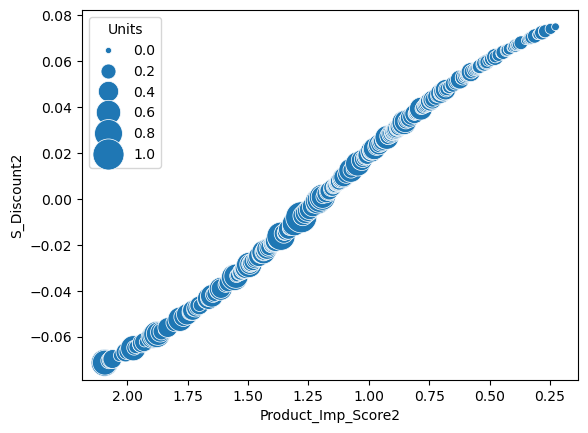


Ready to run the model
Running with Constraints
Optimization terminated successfully    (Exit mode 0)
            Current function value: 430193.4399817036
            Iterations: 28
            Function evaluations: 238
            Gradient evaluations: 27
Discount Minimum :102
Discount Maximum :97
Curve Inclination : 2.38

      Expected Values
#     ------------------    #

--------- Sales ---------
Variance: -$2,577

--------- Margin ---------
Variance: $5,188

--------- Units ---------
Total: 1,469,129
Variance: 534
Variance %: %0.04

--------- Ratios ---------
Price Variance (weighted AVG): %0.85
AVG Cost Ratio (Price/Cost -1): %761.69
Final S-Surve, with with the optimizer and constraints


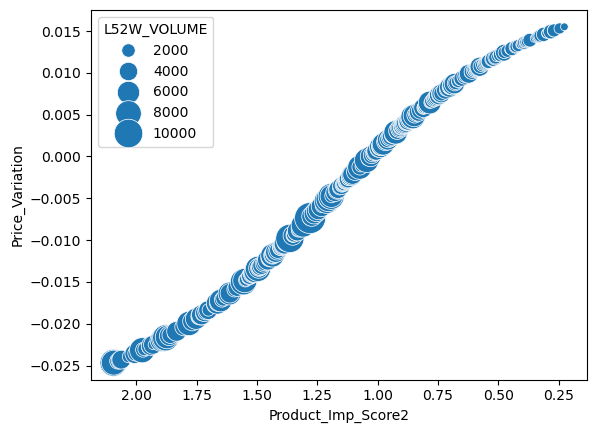


Running Scenario: 2 - Similar to 1 but allowing 25% price var Model Type: SLSQP

Ideal S-Surve, with no constraints or optimization


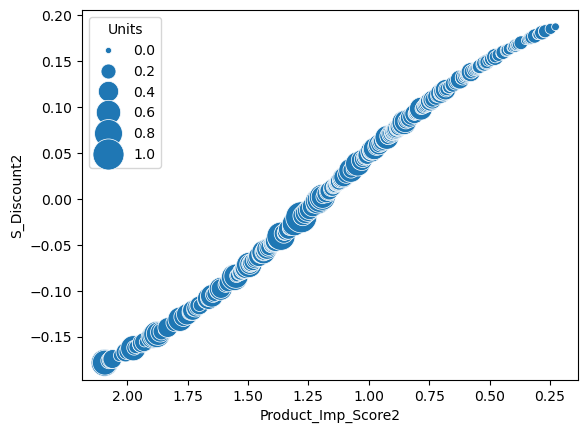


Ready to run the model
Running with Constraints
Optimization terminated successfully    (Exit mode 0)
            Current function value: 428411.3068934339
            Iterations: 39
            Function evaluations: 265
            Gradient evaluations: 38
Discount Minimum :101
Discount Maximum :97
Curve Inclination : 7.78

      Expected Values
#     ------------------    #

--------- Sales ---------
Variance: -$6,447

--------- Margin ---------
Variance: $2,335

--------- Units ---------
Total: 1,469,596
Variance: 1,001
Variance %: %0.07

--------- Ratios ---------
Price Variance (weighted AVG): %0.95
AVG Cost Ratio (Price/Cost -1): %761.35
Final S-Surve, with with the optimizer and constraints


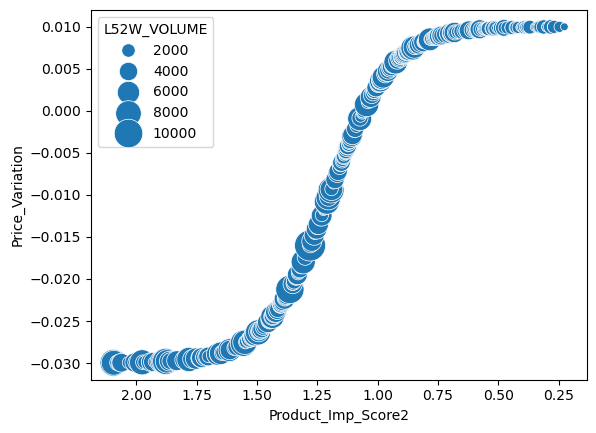


Running Scenario: 3 - Similar to 2 but less aggressive on Business Constraints Model Type: SLSQP

Ideal S-Surve, with no constraints or optimization


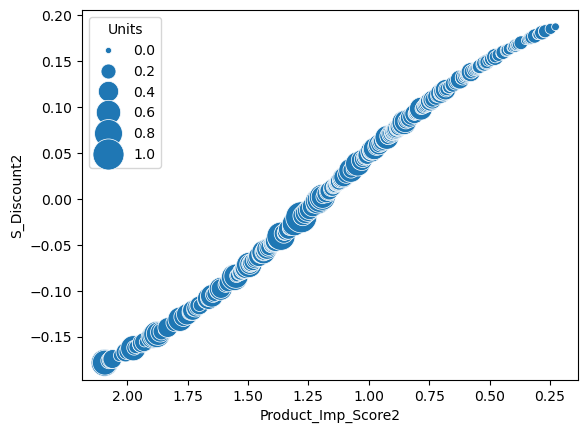


Ready to run the model
Running with Constraints
Optimization terminated successfully    (Exit mode 0)
            Current function value: 214751.31895575934
            Iterations: 76
            Function evaluations: 422
            Gradient evaluations: 76
Discount Minimum :101
Discount Maximum :98
Curve Inclination : 1.80

      Expected Values
#     ------------------    #

--------- Sales ---------
Variance: -$872

--------- Margin ---------
Variance: $2,811

--------- Units ---------
Total: 1,468,875
Variance: 280
Variance %: %0.02

--------- Ratios ---------
Price Variance (weighted AVG): %0.41
AVG Cost Ratio (Price/Cost -1): %761.34
Final S-Surve, with with the optimizer and constraints


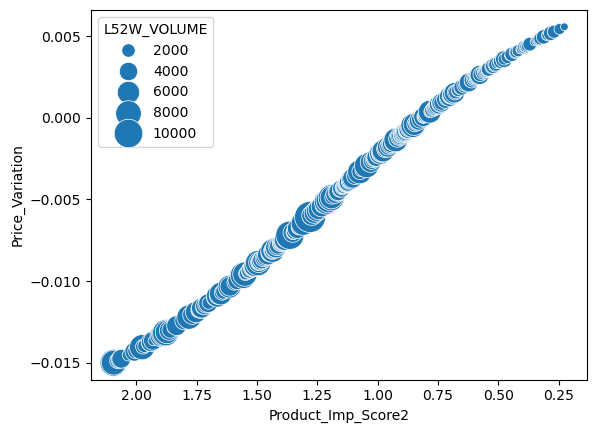


Running Scenario: 4 - Similar to 3 but almost no Business Constraints Model Type: SLSQP

Ideal S-Surve, with no constraints or optimization


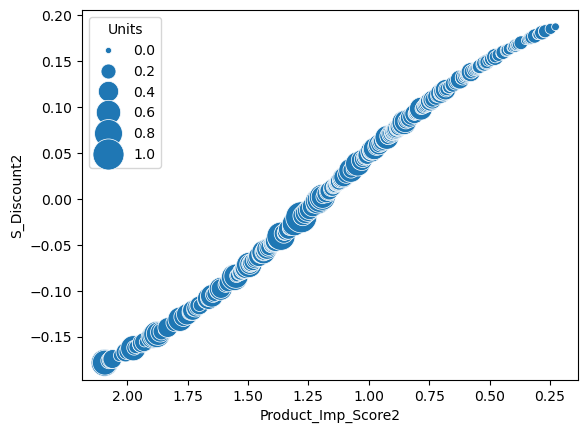


Ready to run the model
Running with Constraints
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.09801917585355113
            Iterations: 20
            Function evaluations: 129
            Gradient evaluations: 19
Discount Minimum :117
Discount Maximum :82
Curve Inclination : 0.00

      Expected Values
#     ------------------    #

--------- Sales ---------
Variance: -$0

--------- Margin ---------
Variance: -$0

--------- Units ---------
Total: 1,468,595
Variance: 0
Variance %: %0.00

--------- Ratios ---------
Price Variance (weighted AVG): %-0.00
AVG Cost Ratio (Price/Cost -1): %761.03
Final S-Surve, with with the optimizer and constraints


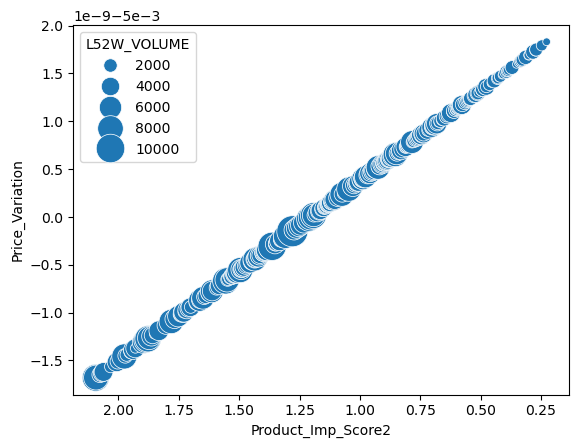

In [29]:
PriceOptimizer(scenario = "1 - Following the Brief Specs Model Type: SLSQP",
               OptVariable = 'Margin',
               PriceVariationMin = -10,
               PriceVariationMax = +10,
               C1_Units_Variation=0.03,
               C3_Manufact_Sales_Var = 0.03,
               C4_Manufact_Margin_Var = 0.03,
               C5_EachRetailer_Margin_Var = 0.02,
               C6_Each_Retailer_Toward_25 = 0.25,
               ProductImportanceInclination = 2,
               MinInclination = 1,
               Optmethod='SLSQP' )

PriceOptimizer(scenario = "2 - Similar to 1 but allowing 25% price var Model Type: SLSQP",
               OptVariable = 'Margin',
               PriceVariationMin = -25,
               PriceVariationMax = +25,
               C1_Units_Variation=0.03,
               C3_Manufact_Sales_Var = 0.03,
               C4_Manufact_Margin_Var = 0.03,
               C5_EachRetailer_Margin_Var = 0.02,
               C6_Each_Retailer_Toward_25 = 0.25,
               ProductImportanceInclination = 2,
               MinInclination = -5,
               Optmethod='SLSQP' )

PriceOptimizer(scenario = "3 - Similar to 2 but less aggressive on Business Constraints Model Type: SLSQP",
               OptVariable = 'Margin',
               PriceVariationMin = -25,
               PriceVariationMax = +25,
               C1_Units_Variation=0.015,
               C3_Manufact_Sales_Var = 0.015,
               C4_Manufact_Margin_Var = 0.01,
               C5_EachRetailer_Margin_Var = 0.01,
               C6_Each_Retailer_Toward_25 = 0.5,
               ProductImportanceInclination = 2,
               MinInclination = -5,
               Optmethod='SLSQP' )

PriceOptimizer(scenario = "4 - Similar to 3 but almost no Business Constraints Model Type: SLSQP",
               OptVariable = 'Margin',
               PriceVariationMin = -25,
               PriceVariationMax = +25,
               C1_Units_Variation=0.0,
               C3_Manufact_Sales_Var = 0.00,
               C4_Manufact_Margin_Var = 0.00,
               C5_EachRetailer_Margin_Var = 0.00,
               C6_Each_Retailer_Toward_25 = 0.75,
               ProductImportanceInclination = 2,
               MinInclination = -5,
               Optmethod='SLSQP' )
#SLSQP #COBYLA #'trust-constr'#

FinalDF.to_csv("OptimizedPrices.csv")
ModelParameters.to_csv("ModelParameters.csv")

In [30]:
FinalDF.to_csv("OptimizedPrices.csv")
ModelParameters.to_csv("ModelParameters.csv")

In [31]:
FinalDF.head()

,PRODUCT_ID,CATEGORY,BRAND,PRODUCT_DESCRIPTION,FORM,SIZE_VALUE,UOM,PRICE_GROUP,SLOPE_GROUP,RETAILER,...,Expected_Sales_Var,S_Price_Final,BP_LP_Ratio,PromoRatio,S_Discount2,Suggested_LP,Suggested_BP,Suggested_MAP,Price_Variation,scenario
0,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Walmart Corp-RMA,...,56.578293,3.126984,1.432258,0.889640,0.047584,3.126984,4.478648,3.984383,0.008705,1 - Following the Brief Specs Model Type: SLSQP
1,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Target Corp-RMA,...,-73.426184,3.056237,1.514469,0.898089,-0.042373,3.056237,4.628578,4.156876,-0.017287,1 - Following the Brief Specs Model Type: SLSQP
2,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Kroger Corp-RMA,...,-51.444199,2.851446,1.624138,0.840764,-0.040401,2.851446,4.631141,3.893698,-0.016743,1 - Following the Brief Specs Model Type: SLSQP
3,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,Albertsons Corp-RMA,...,3.209444,3.273504,1.590214,0.861538,0.020534,3.273504,5.205572,4.484800,0.001071,1 - Following the Brief Specs Model Type: SLSQP
4,A001,ANALGESICS,ADVIL,ADVIL CAPLET 24 CT,CAPLET,24,CT,ADVIL_24CT,ADVIL_CAPLET_SLOPE,CVS Corp-RMA,...,10.229094,3.523649,1.492877,0.864504,0.030270,3.523649,5.260376,4.547615,0.003889,1 - Following the Brief Specs Model Type: SLSQP
